----------------------------------------------------------------------------------------------------

# ***Request body - FastAPI***

https://fastapi.tiangolo.com/tutorial/body/

----------------------------------------------------------------------------------------------------

# ***1. Tipificação de dados*** 

É possível, com o uso da biblioteca 'Pydantic', fazermos "Coerção de Tipos" e outras coisas a mais para o FastAPI. Podemos, por exemplo parametrizar e facilitar os 'requests' da nossa API de uma forma diferente utilizando essa biblioteca muito conhecida no Python moderno.

Façamos algumas mudanças no nosso código:

In [ ]:
# importe a biblioteca
from pydantic import BaseModel

#Criando mapeamento
class Post(BaseModel):
    title: str
    date: datetime = datetime.now(UTC)
    publised: bool = False


#Criando novo método
@app.post('/posts/')
def create_post(post: Post):

    return post

----------------------------------------------------------------------------------------------------

# ***2. Criando o primeiro riquest com 'Flashpost' (Substituindo o ThunderCliente)*** 

Vamos definir criar a nossa conexão primeiro:

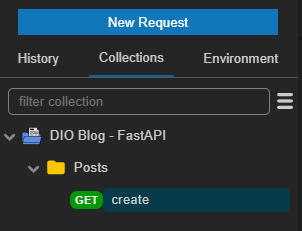

## ***2.1. Definimos a porta para conexao*** 

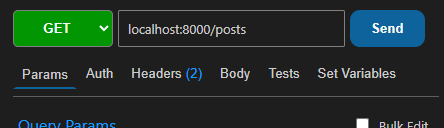

Apertamos em 'Send'.

O seguinte erro aparecerá:

    {
    1 items
    "detail"
    :
        [
        1 items
        0
        :
        {
        4 items
        "type":"missing"
        "loc"
        :
        [
        2 items
        0:"query"
        1:"published"
        ]
        "msg":"Field required"
        "input":NULL
        }
        ]
    }

Ele informa que há um 'missing'. O que esta correto. Vamos corrigir

## ***2.2. Corrindo para POST*** 

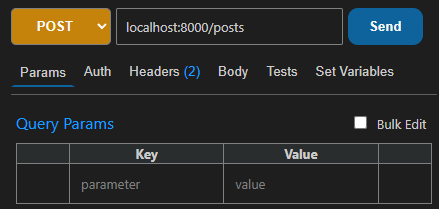

Utilizamos 'Send' novamente.

Seguinte informação:

    {
        1 items
        "detail"
        :
        [
        1 items
        0
        :
        {
        4 items
        "type":"missing"
        "loc"
        :
        [
        2 items
        0:"body"
        1:"title"
        ]
        "msg":"Field required"
        "input":{}0 items
        }
        ]
    }

## ***2.3. Corrindo para a falta de body JSON*** 

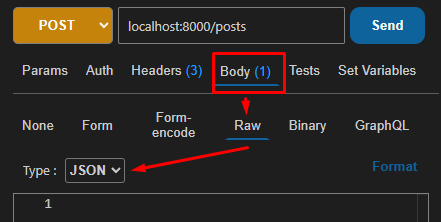

Coloque um JSON vázio:

    {}

Em seguida, ele denuncia o outro erro, a falta do 'title' que é obrigatório.

Exemplo:

    "detail"
    :
        [
        1 items
        0
        :
        {
        4 items
        "type":"missing"
        "loc"
        :
        [
        2 items
        0:"body"
        1:"title"
        ]
        "msg":"Field required"
        "input":{}0 items
        }
        ]
    }

## ***2.4. 'title' - uso obrigatório*** 

Vá no corpo do JSON e defina um 'title' e dê a ele um valor. No meu caso, fiz:

    {
        "title": "Criando endpoints do tipo post com body parameter"
    }

Resposta esperada:

    {
        3 items
        "title":"Criando endpoints do tipo pos...
        "date":"2026-03-31T18:49:37.753429Z"
        "published":false
    }

----------------------------------------------------------------------------------------------------

# ***3. Adicionando mais argumentos ao decorador @app.post*** 

## ***3.1. Módulo 'status' do FastAPI - status_code***

Vamos requisitar mais um móduloo do FastAPI chamado 'status':

In [ ]:
from fastapi import FastAPI, status

E atualizamos o nosso decorador @app.post:

In [ ]:
@app.post('/posts/', status_code= status)
def create_post(post: Post):

    return post

O que ele faz?
Permite acessar todos os estados codes padrões, exemplo:

In [ ]:
@app.post('/posts/', status_code= status.HTTP_201_CREATED)
def create_post(post: Post):

    return post

Deveriamos inclusive usa-lo, já que estamos realmente criando um novo status post.

Quando voltamos ao FlashPost, e clicamos em 'Send' novamente, ele atualiza o status:

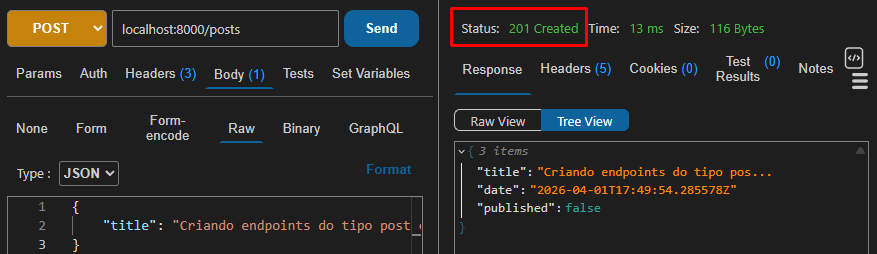

O status HTTP_201_CREATED é exatamente o que definimos no código, por isso o 201.

----------------------------------------------------------------------------------------------------

# ***4. Aplicando método append() e model_dump*** 

## ***4.1. model_dump***

O que ele é?
Retorna a representação da classe em um dicionário. O que é ótimo para utilizamos a classe Post que criamos pelo BaseModel da biblioteca pydantic em um dicionário de forma automática


In [ ]:
#Criando novo método
@app.post('/posts/', status_code= status.HTTP_201_CREATED)
def create_post(post: Post):

    return post